# 13. Masking

Selecting points with `sylva.geo.masks`: by polygons read from a file, by the
raster cell under each point, by an expression over the attributes, and by
the distance to another cloud. A mask is a boolean array, one entry per
point, so masks from different sources combine with `&`, `|` and `~`. The
[guide](../guide/masking.md) has the details.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.style.use("sylva.mplstyle")     # shared figure style; C0 to C7 are the Okabe-Ito colours
GROUND, WOOD, LEAF, GRASS, CONTEXT = "#997A5C", "#4D2B12", "#009E73", "#E69F00", "0.8"   # the same in every notebook
DIVERGING = "RdBu_r"                # for signed differences, centred on zero
LABELS = ListedColormap(["#332288", "#88CCEE", "#44AA99", "#117733", "#999933", "#DDCC77",
                         "#CC6677", "#882255", "#AA4499"])   # tree ids and clusters: Paul Tol's muted set

import json
from sylva import ground
from sylva.geo import masks

cloud = sylva.read(DATA / "litch_tile.laz")
cloud = ground.normalize_height(cloud, ground.make_dtm(cloud, 0.5, bounds=(0, 0, 20, 20)))

## Polygons

`read_polygons` reads GeoJSON and ESRI shapefiles. The file below holds two
subplots with a `treatment` property: a rectangle with a circular hole
around the tile's largest stem (excluded, say, for destructive sampling),
and a pentagon. Coordinates are in the tile's frame; polygons are never
reprojected, so they have to be in the cloud's frame.

In [2]:
import tempfile
tmp = Path(tempfile.mkdtemp())
t = np.linspace(0, 2 * np.pi, 33)[:-1]
hole = np.column_stack([4.8 + 1.5 * np.cos(t), 7.5 + 1.5 * np.sin(t)])[::-1].tolist()
features = [
    {"type": "Feature", "properties": {"name": "west", "treatment": "burnt"},
     "geometry": {"type": "Polygon", "coordinates": [[[1, 1], [9, 1], [9, 15], [1, 15], [1, 1]], hole + hole[:1]]}},
    {"type": "Feature", "properties": {"name": "east", "treatment": "control"},
     "geometry": {"type": "Polygon", "coordinates": [[[11, 3], [19, 3], [19, 11], [15, 19], [11, 11], [11, 3]]]}},
]
json.dump({"type": "FeatureCollection", "features": features}, open(tmp / "subplots.geojson", "w"))

subplots = masks.read_polygons(tmp / "subplots.geojson")
print(len(subplots), "features:", [f.properties for f in subplots])
which = masks.polygon_index(cloud, subplots)             # index of the polygon, -1 outside all
for i, f in enumerate(subplots):
    print(f"{f.properties['name']:5s} {np.sum(which == i):>9,} points")
burnt = masks.crop_polygons(cloud, subplots[[f.properties["treatment"] == "burnt" for f in subplots]])
print("burnt subplot:", burnt)

2 features: [{'name': 'west', 'treatment': 'burnt'}, {'name': 'east', 'treatment': 'control'}]
west    500,045 points
east    362,634 points
burnt subplot: PointCloud(n=500,045, attrs=['classification', 'gps_time', 'height', 'intensity', 'number_of_returns', 'point_source_id', 'return_number', 'scan_angle', 'user_data'])


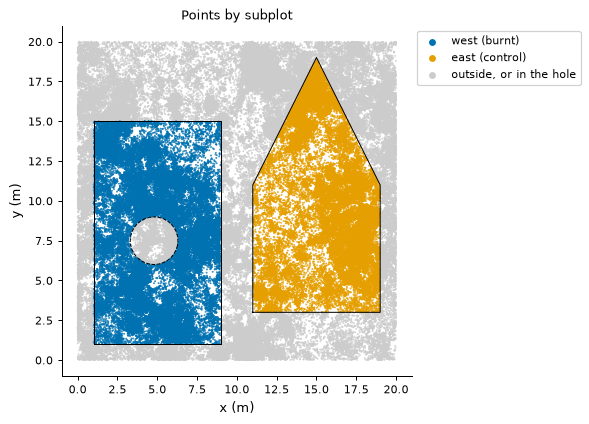

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.6))
colours = np.array([CONTEXT, "C0", "C1"])
ax.scatter(cloud.x[::10], cloud.y[::10], s=0.2, c=colours[which[::10] + 1])
for i, f in enumerate(subplots):
    for part in f.parts:
        ax.plot(*part.exterior.T, "k", lw=0.8)
        for h in part.holes:
            ax.plot(*h.T, "k--", lw=0.8)
    ax.scatter([], [], s=20, c=f"C{i}", label=f"{f.properties['name']} ({f.properties['treatment']})")
ax.scatter([], [], s=20, c=CONTEXT, label="outside, or in the hole")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.set(aspect="equal", xlabel="x (m)", ylabel="y (m)", title="Points by subplot");

## Raster masks

`raster_mask` tests the raster cell under each point against a range
(`min`, `max`, inclusive) or a set of `values`. With the CHM it separates
the points under tall canopy from those in the gaps. Points outside the
raster or over NaN cells are never kept.

under canopy of 10 m or more: 79% of the points; in cells below 2 m: 12%
vegetation between 0.3 and 2 m: 61% of it under tall canopy, 28% in the gaps


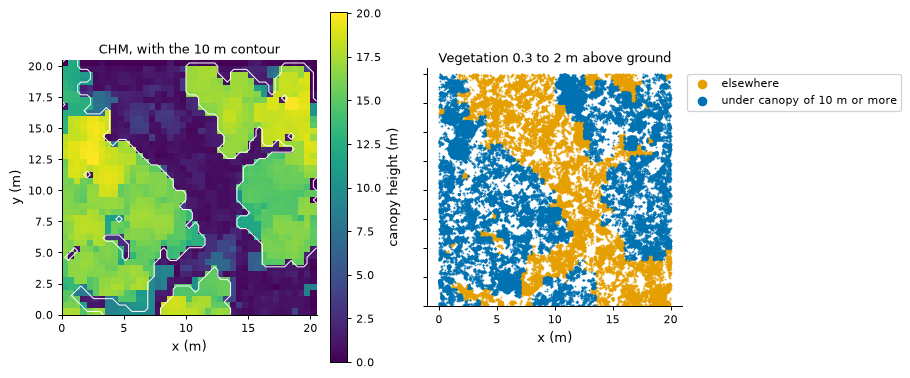

In [4]:
chm = ground.make_chm(cloud, 0.5, bounds=(0, 0, 20, 20))
under_tall = masks.raster_mask(cloud, chm, min=10)
in_gaps = masks.raster_mask(cloud, chm, max=2)
print(f"under canopy of 10 m or more: {under_tall.mean():.0%} of the points; in cells below 2 m: {in_gaps.mean():.0%}")
low_veg = masks.expression(cloud, "0.3 < height < 2 & classification == 4")
print(f"vegetation between 0.3 and 2 m: {np.mean(under_tall[low_veg]):.0%} of it under tall canopy, "
      f"{np.mean(in_gaps[low_veg]):.0%} in the gaps")

fig, ax = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
im = ax[0].imshow(chm.data, origin="lower", extent=(chm.xmin, chm.xmax, chm.ymin, chm.ymax))
ax[0].contour(chm.data >= 10, levels=[0.5], extent=(chm.xmin, chm.xmax, chm.ymin, chm.ymax), colors="w", linewidths=0.8)
fig.colorbar(im, ax=ax[0], shrink=0.9, label="canopy height (m)")
ax[0].set(title="CHM, with the 10 m contour", xlabel="x (m)", ylabel="y (m)")
m = low_veg & under_tall
ax[1].scatter(cloud.x[low_veg & ~m][::4], cloud.y[low_veg & ~m][::4], s=0.2, c="C1", label="elsewhere")
ax[1].scatter(cloud.x[m][::4], cloud.y[m][::4], s=0.2, c="C0", label="under canopy of 10 m or more")
ax[1].set(aspect="equal", title="Vegetation 0.3 to 2 m above ground", xlabel="x (m)")
ax[1].legend(markerscale=15, loc="upper left", bbox_to_anchor=(1.0, 1.0));

## Expressions

`cloud.where`, `masks.expression` and `masks.crop_expression` take a
condition over `x`, `y`, `z` and the attributes, which the Rust core parses
and evaluates; the text is never run as Python. Comparisons can be chained,
`in` tests membership, and `&` and `|` bind more loosely than comparisons,
so no parentheses are needed where NumPy would need them.

In [5]:
veg = cloud.where("height > 2 & classification != 2")
numpy_way = cloud[(cloud.attrs["height"] > 2) & (cloud.attrs["classification"] != 2)]
print(veg, "| the same as the NumPy mask:", np.array_equal(veg.xyz, numpy_way.xyz))
print("chained:", masks.expression(cloud, "1.3 <= height < 5").sum(),
      "| membership:", masks.expression(cloud, "classification in (3, 4, 5)").sum(),
      "| arithmetic:", masks.expression(cloud, "x + y < 10 & not (height > 1)").sum())
try:
    cloud.where("hieght > 2")
except ValueError as err:
    print(err)

PointCloud(n=917,360, attrs=['classification', 'gps_time', 'height', 'intensity', 'number_of_returns', 'point_source_id', 'return_number', 'scan_angle', 'user_data']) | the same as the NumPy mask: True
chained: 144080 | membership: 1376604 | arithmetic: 74298
unknown attribute 'hieght' at position 0 (did you mean 'height'?); the cloud has: x, y, z, classification, gps_time, height, intensity, number_of_returns, point_source_id, return_number, scan_angle, user_data
    hieght > 2
    ^


## Distance to another cloud

`near` keeps the points within a distance of another cloud and
`difference` returns those beyond it, which is change detection between
two epochs of the same scene. Here the second epoch is a copy of the tile
with a 3 x 3 m block between 0.5 and 6 m removed, which takes a section of
a stem and the shrubs beside it, as if they had been cut, and every
remaining point moved by 5 mm of random noise, as a
re-survey would. `difference(before, after, d)` should find the block and
nothing else, provided `d` is above the noise and the point spacing.

In [6]:
block = (cloud.x > 14) & (cloud.x < 17) & (cloud.y > 14) & (cloud.y < 17) & (cloud.z > 0.5) & (cloud.z < 6)
rng = np.random.default_rng(1)
kept = cloud[~block]
after = sylva.PointCloud(kept.xyz + rng.normal(0, 0.005, kept.xyz.shape), kept.attrs)
print(f"{block.sum():,} points removed")


def in_block(c):
    return (c.x > 14) & (c.x < 17) & (c.y > 14) & (c.y < 17) & (c.z > 0.5) & (c.z < 6)


for d in (0.01, 0.05, 0.10):
    lost = masks.difference(cloud, after, d)
    print(f"d = {d * 100:4.0f} cm: {len(lost):>9,} points found, {in_block(lost).sum():,} of them in the block")
print("appeared (after against before, 5 cm):", len(masks.difference(after, cloud, 0.05)))

6,646 points removed


d =    1 cm:   402,403 points found, 6,646 of them in the block


d =    5 cm:     6,310 points found, 6,310 of them in the block


d =   10 cm:     5,606 points found, 5,606 of them in the block


appeared (after against before, 5 cm): 0


At 1 cm the noise itself reads as change. At 5 cm only points of the
block are found, but not all of them: a removed point within 5 cm of a
point that stayed, on the faces of the block, is matched to that neighbour.
A larger distance loses more of the block's edge, so choose it just above
the registration error and the point spacing.

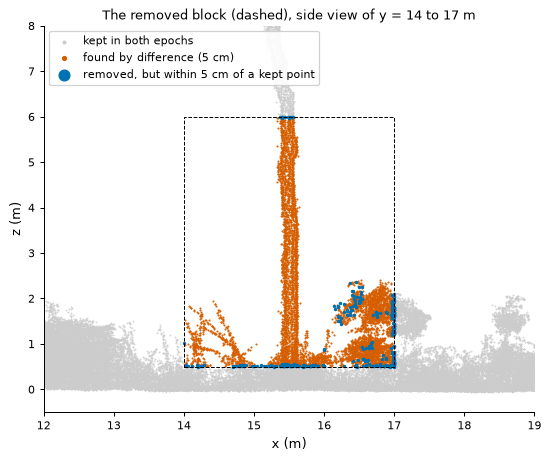

In [7]:
lost = masks.difference(cloud, after, 0.05)
missed = block & ~masks.near(cloud, lost, 1e-6)
fig, ax = plt.subplots(figsize=(6, 5))
side = (cloud.y > 14) & (cloud.y < 17)
ax.scatter(cloud.x[side & ~block], cloud.z[side & ~block], s=0.2, c=CONTEXT, label="kept in both epochs")
ax.scatter(lost.x, lost.z, s=0.4, c="C3", label="found by difference (5 cm)")
ax.scatter(cloud.x[missed], cloud.z[missed], s=3, c="C0", label="removed, but within 5 cm of a kept point")
ax.add_patch(plt.Rectangle((14, 0.5), 3, 5.5, fill=False, ls="--", lw=0.8, ec="k"))
ax.set(xlim=(12, 19), ylim=(-0.5, 8), xlabel="x (m)", ylabel="z (m)",
       title="The removed block (dashed), side view of y = 14 to 17 m")
ax.legend(markerscale=5, loc="upper left");